In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import sim_ranking as sr
import ml_tools as mlt

In [ ]:
def display_scenario(event_id: str, site_int: str, gnn_results_df: pd.DataFrame, dist_matrix: pd.DataFrame, obs_data: sr.ObservedData, 
                     cim_results_df: pd.DataFrame = None, n_obs_sites: int = 5, emp_gmm_params: pd.DataFrame = None):    
    if f"{event_id}_{site_int}" in gnn_results_df.index:
        # Plots
        cur_obs_sites = sr.plot_ind_scenarios.get_obs_sites(event_id, site_int, gnn_results_df, dist_matrix, n_obs_sites=n_obs_sites)
        sr.plot_ind_scenarios.create_2plot_log(event_id, site_int, cur_obs_sites, gnn_results_df, cim_results_df, obs_data, dist_matrix, emp_gmm_params=emp_gmm_params)

        # Info
        site_info_df = sr.plot_ind_scenarios.get_site_info_df(event_id, site_int, cur_obs_sites, obs_data, dist_matrix)
        display(site_info_df)
    else:
        print(f"No results for {event_id}_{site_int}")

In [3]:
wdata = Path("/Users/claudy/dev/work/data")
model_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/gnn/0218_0800_full_v2p1")

In [4]:
event_id = "3468575"
run_config = sr.ml.RunConfig.from_yaml(model_dir / "run_config.yaml")

In [5]:
# Load NZGMDB data
obs_data = sr.data.load_obs_nzgmdb(wdata / run_config.rel_obs_data_ffp)

In [6]:
# Distance matrix
dist_matrix = sr.utils.calculate_distance_matrix(obs_data.sites, obs_data.site_df)

In [ ]:
# Load the empirical GMM predictions
emp_gmm_params = sr.data.load_emp_gmm_params( wdata / "sim_ranking/emp_gm_params/nzgmdb_v4p2" / "emp_gm_params_400MaxRjb.parquet" )

### Prediction With Observation At SoI

In [8]:

obs_sites = obs_data.event_sites[event_id]

pred_df = pd.read_parquet(model_dir / "3468575/predictions.parquet")
pred_df["site_int"] = pred_df.index.values.astype(str)
pred_df.index = mlt.array_utils.numpy_str_join("_", event_id, pred_df.index.values.astype(str))
pred_df = pred_df.loc[np.isin(pred_df["site_int"], obs_sites)]

# Add observed GM at the SOIs (if available)
pred_df[run_config.ims] = np.log(obs_data.record_df.loc[pred_df.index, run_config.ims])

In [9]:
# obs_sites[np.isin(obs_sites, pred_df.site_int)]

#### CACS

,rrup,vs30,z1p0,z2p5,tsite,site_int_distance
3468575_CACS,12.895085,435.0,595.0,2.675,6.79,0.000000
3468575_CACS,12.895085,435.0,595.0,2.675,6.79,0.000000
3468575_RHSC,6.465248,286.0,445.0,1.925,5.20,6.520079
3468575_SMTC,10.908524,219.0,695.0,3.375,6.34,6.993675
3468575_TPLC,11.923393,398.0,787.0,1.475,5.46,8.791689
3468575_REHS,4.856519,155.0,645.0,2.575,4.99,9.523017
3468575_CHHC,3.848923,196.0,515.0,2.175,2.66,9.821135
3468575_SHLC,5.264587,201.0,675.0,2.475,4.96,11.049865
3468575_CCCC,2.838146,182.0,495.0,2.075,2.51,11.279302
3468575_SWNC,25.186716,546.0,287.0,3.825,6.68,12.968033


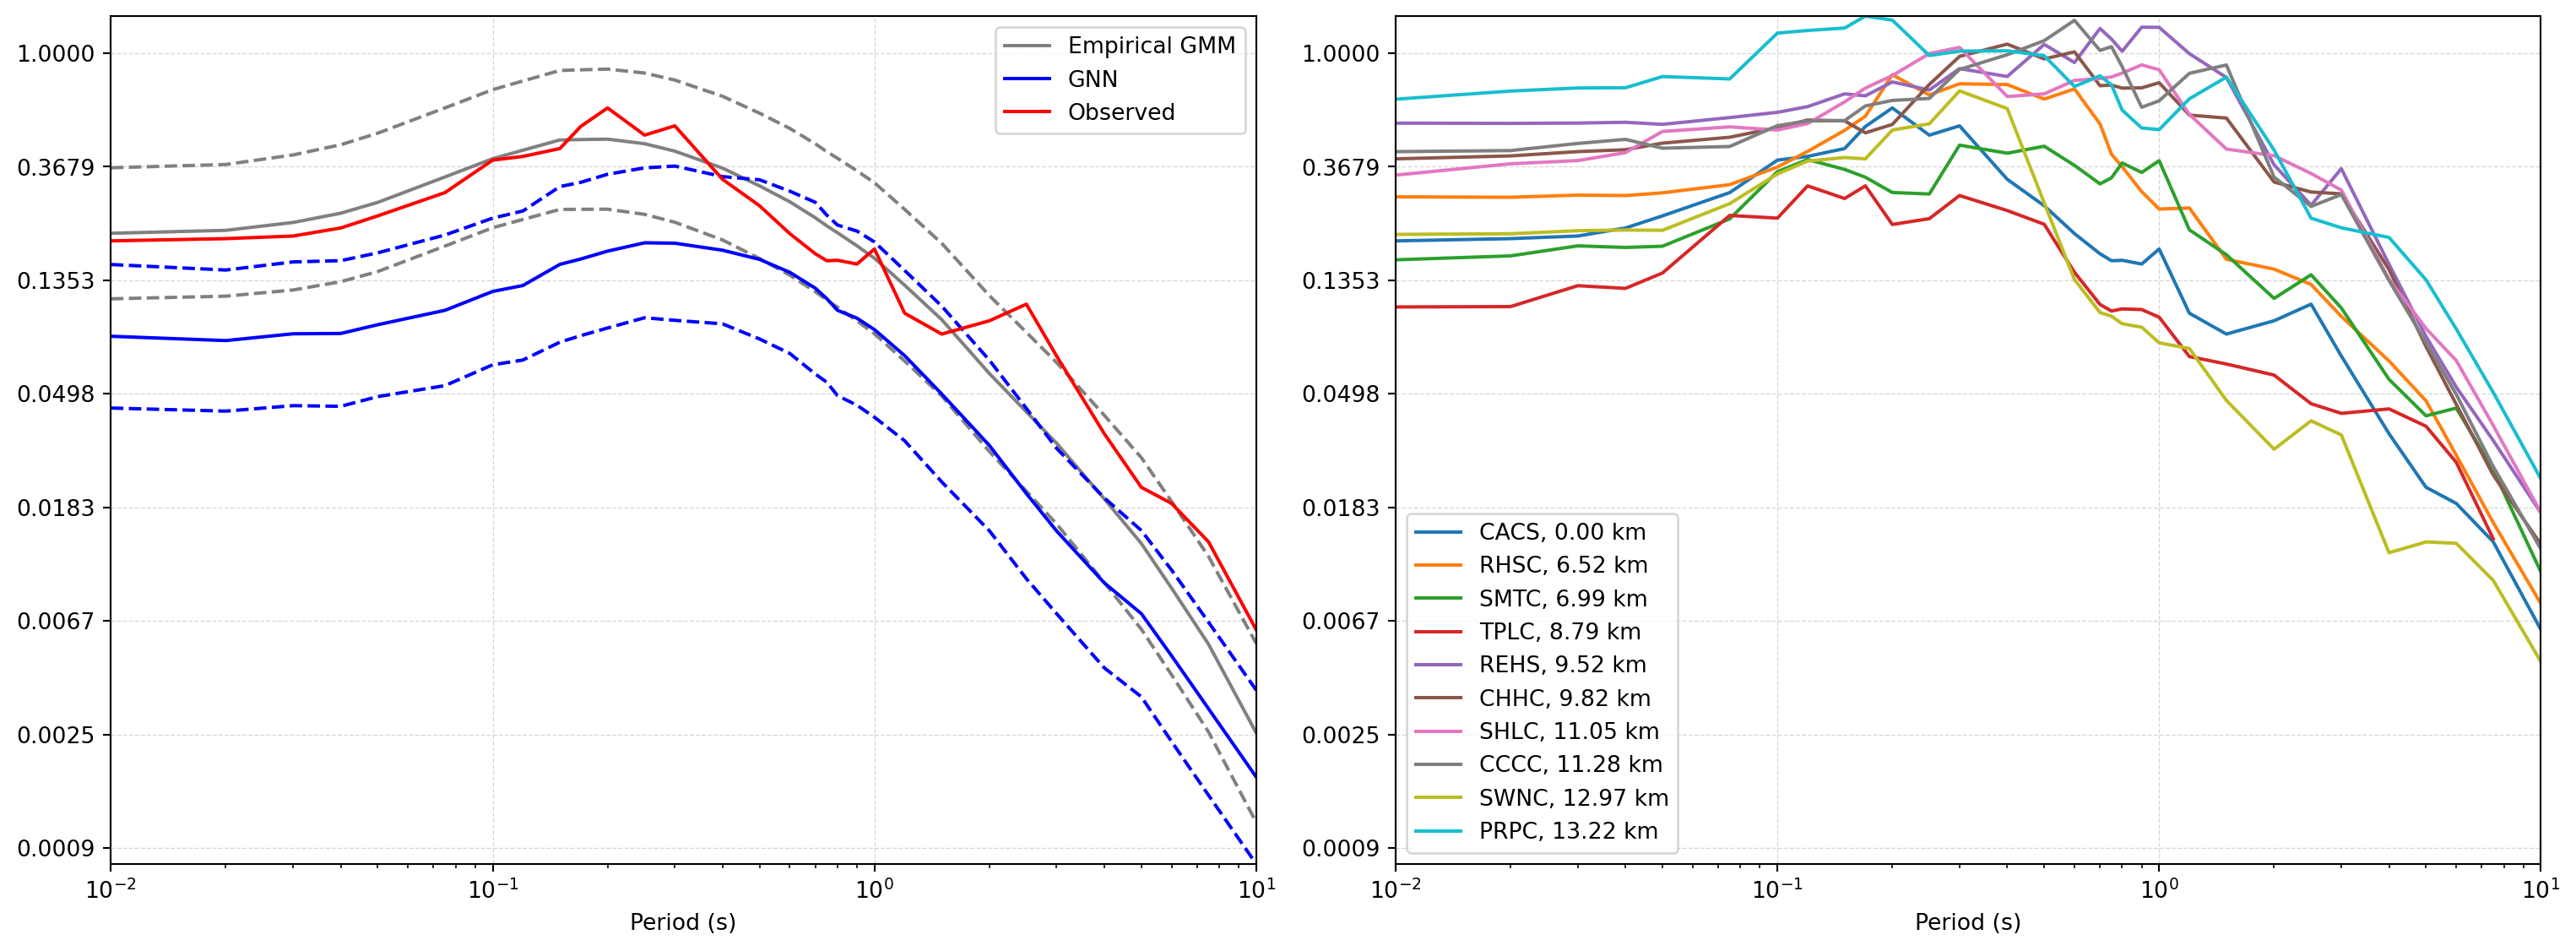

In [10]:
display_scenario(event_id, "CACS", pred_df, dist_matrix, obs_data, n_obs_sites=run_config.max_n_obs_sites, emp_gmm_params=emp_gmm_params)

#### ADCS

,rrup,vs30,z1p0,z2p5,tsite,site_int_distance
3468575_ADCS,78.18721,431.0,1135.0,2.175,5.8,0.000000
3468575_ADCS,78.18721,431.0,1135.0,2.175,5.8,0.000000
3468575_DORC,54.42877,220.0,1035.0,2.075,5.5,27.781973


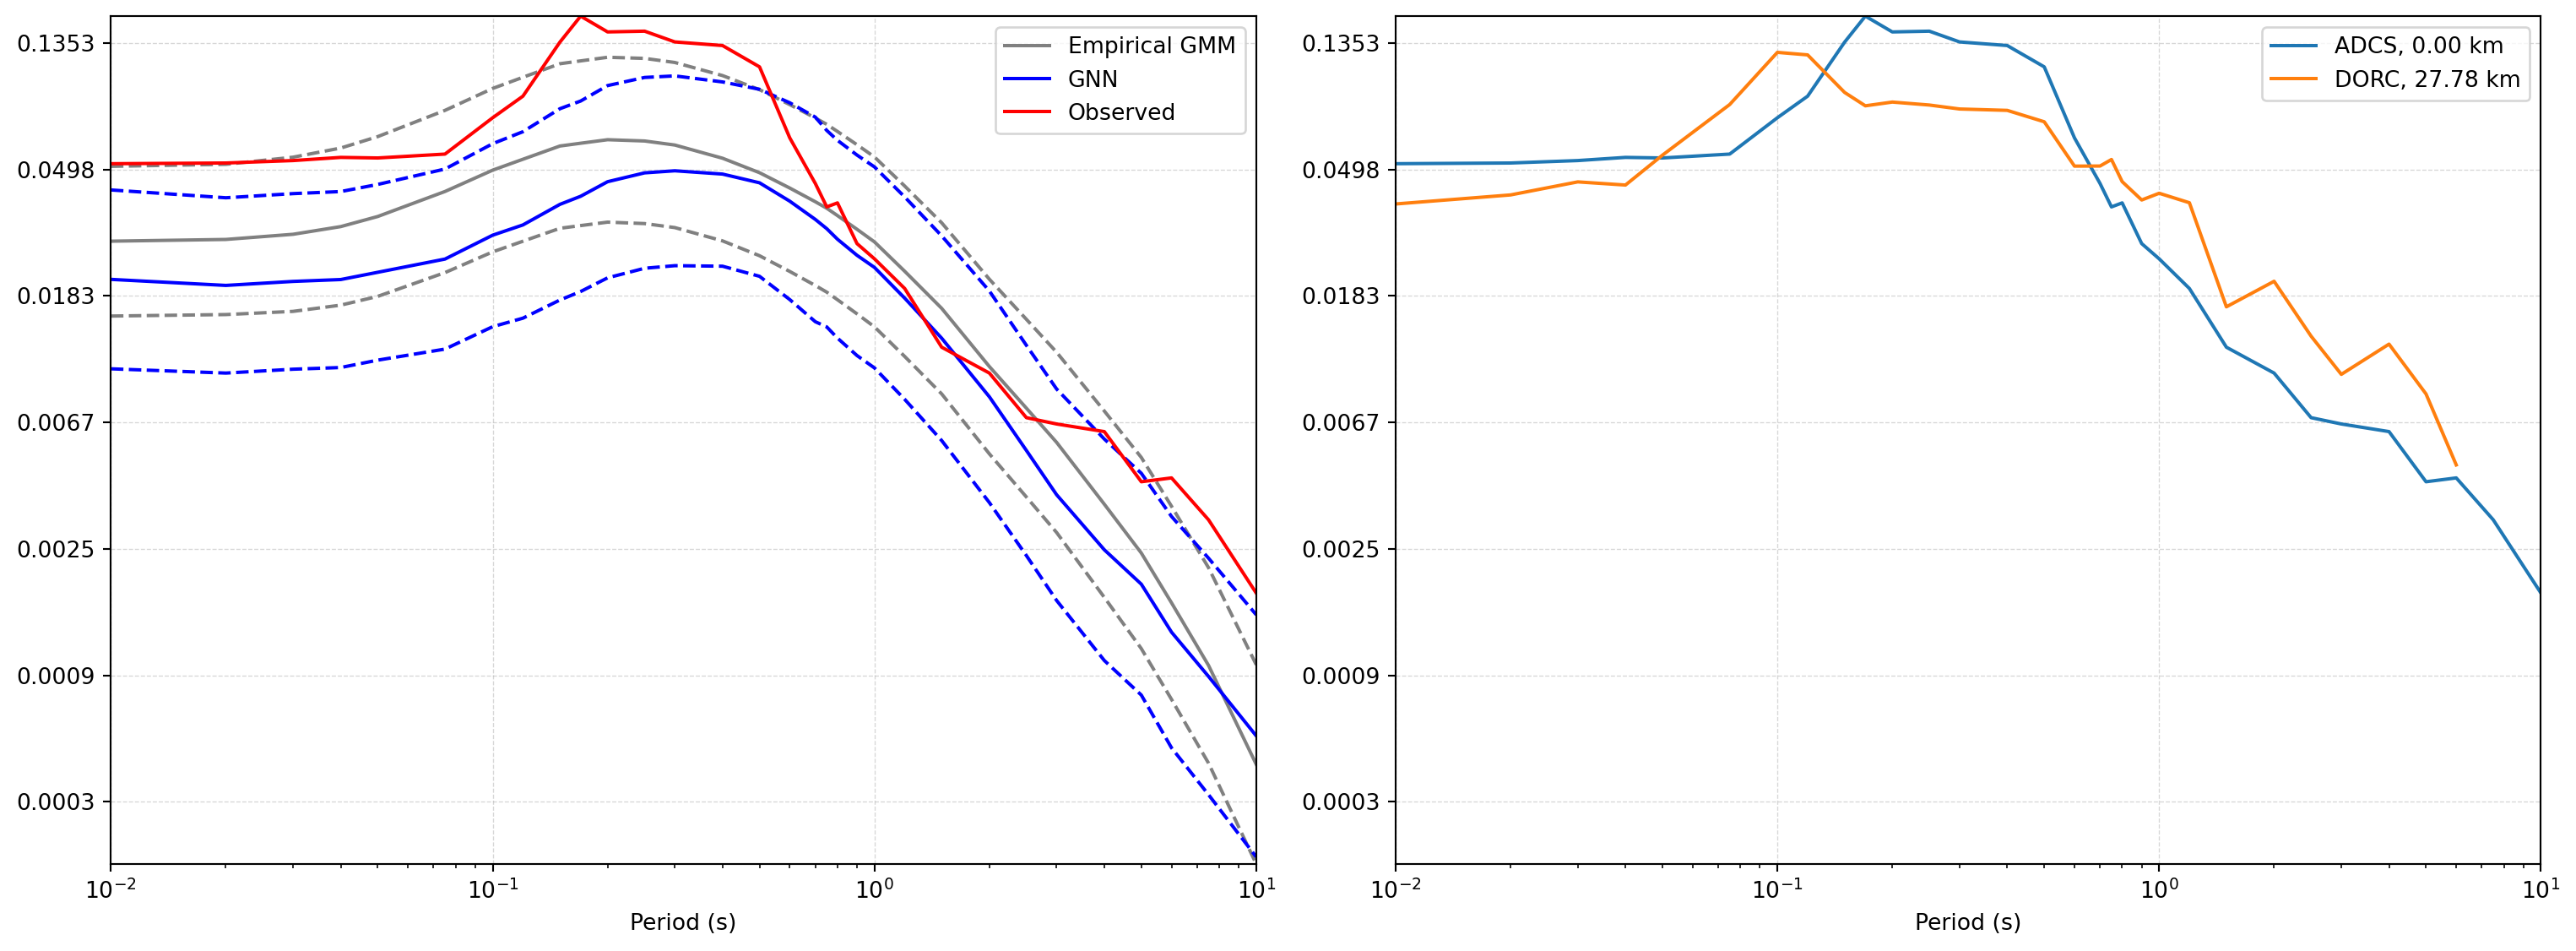

In [11]:
display_scenario(event_id, "ADCS", pred_df, dist_matrix, obs_data, n_obs_sites=run_config.max_n_obs_sites, emp_gmm_params=emp_gmm_params)

#### CCCC

,rrup,vs30,z1p0,z2p5,tsite,site_int_distance
3468575_CCCC,2.838146,182.0,495.0,2.075,2.51,0.000000
3468575_CCCC,2.838146,182.0,495.0,2.075,2.51,0.000000
3468575_CHHC,3.848923,196.0,515.0,2.175,2.66,1.624746
3468575_REHS,4.856519,155.0,645.0,2.575,4.99,2.052052
3468575_PRPC,2.551651,196.0,485.0,2.075,5.28,3.162374
3468575_SHLC,5.264587,201.0,675.0,2.475,4.96,3.866571
3468575_HPSC,4.025552,194.0,645.0,2.225,5.24,6.005060
3468575_RHSC,6.465248,286.0,445.0,1.925,5.20,6.703241
3468575_HVSC,3.792928,348.0,19.0,1.525,0.27,6.823705
3468575_NNBS,3.957129,204.0,685.0,2.175,4.87,7.416691


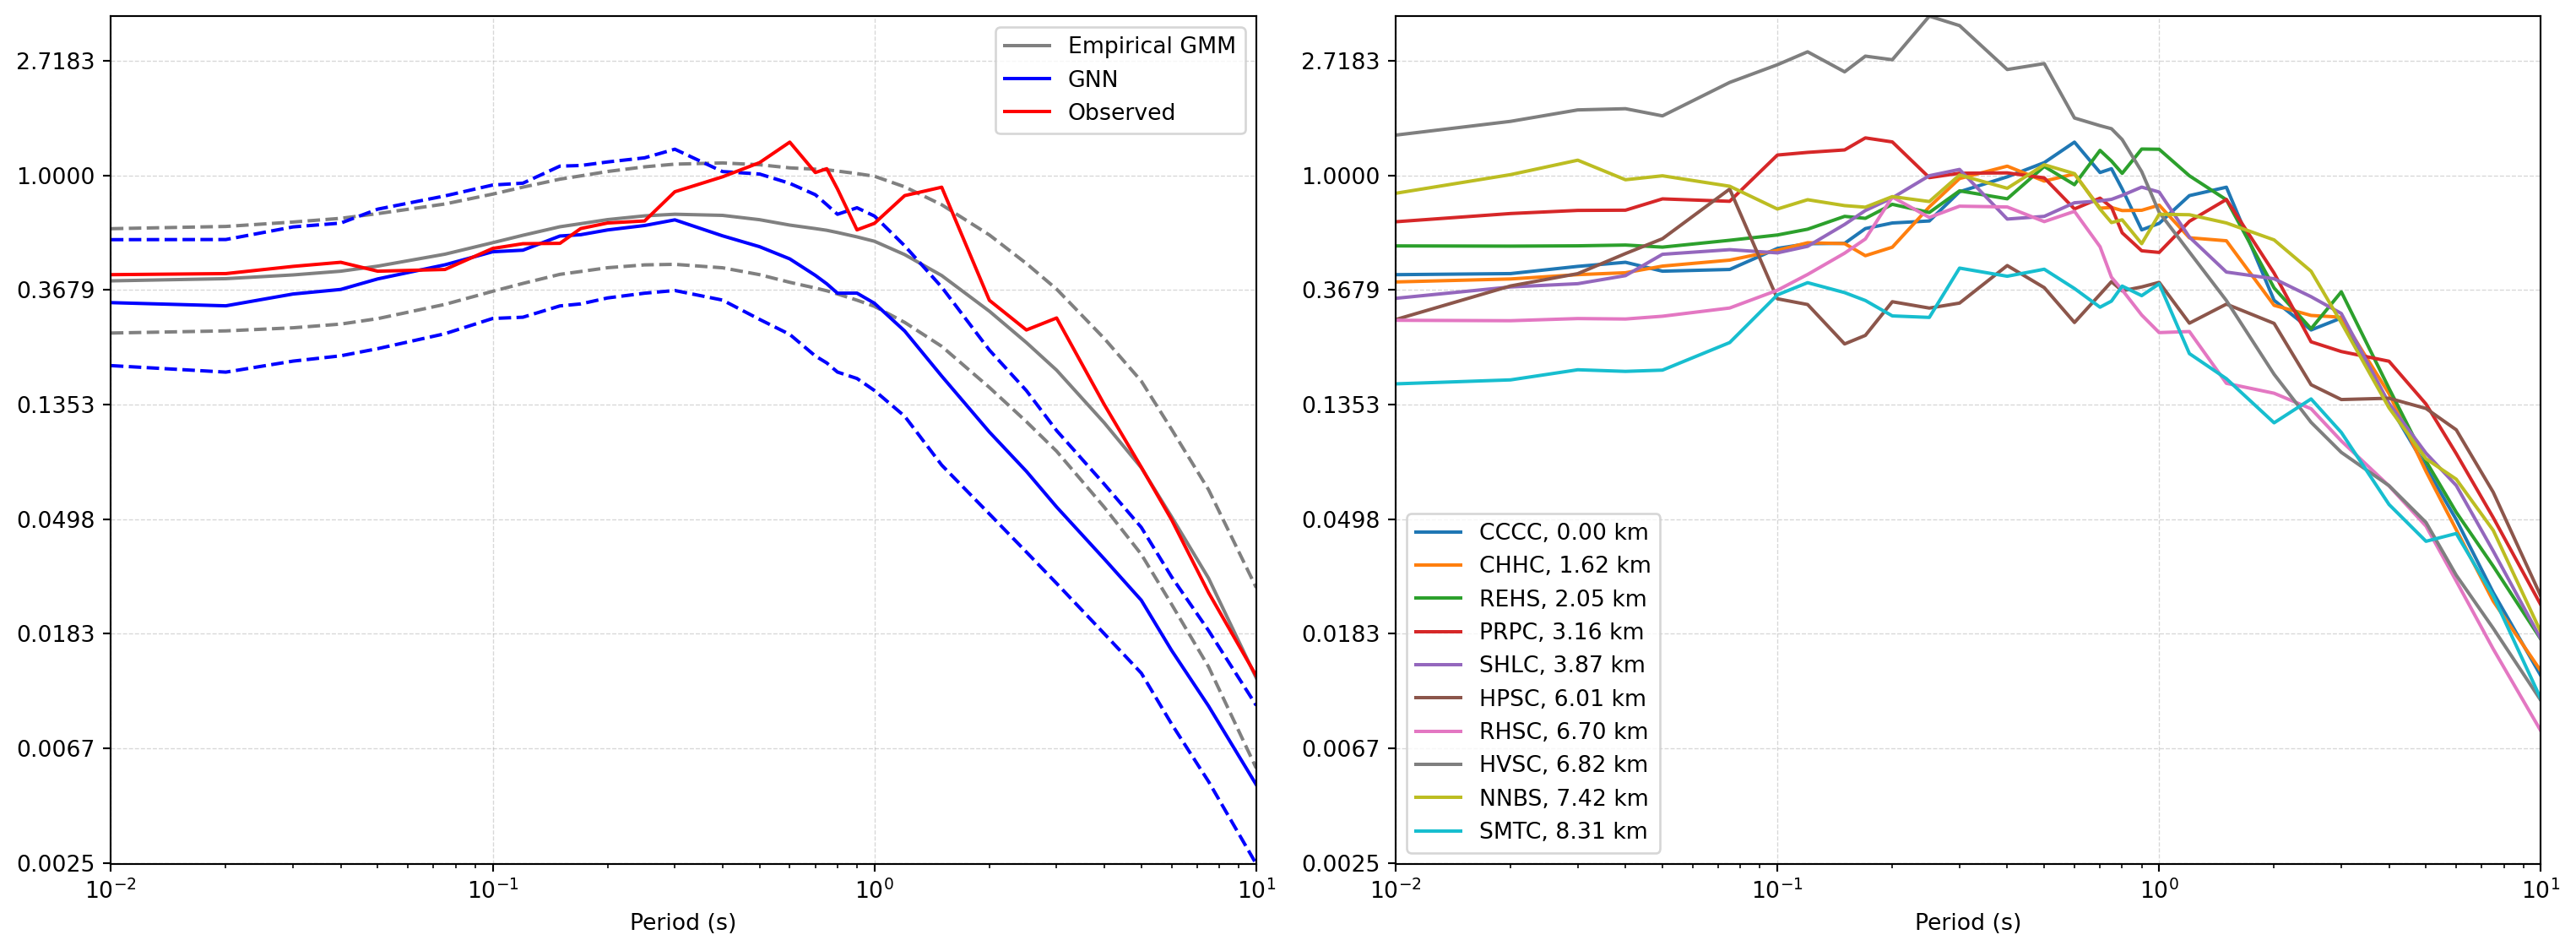

In [12]:
display_scenario(event_id, "CCCC", pred_df, dist_matrix, obs_data, n_obs_sites=run_config.max_n_obs_sites, emp_gmm_params=emp_gmm_params)